In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 4],
    [8, 8], [9, 8], [8, 9],
    [20, 20]   # Outlier
])


In [5]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [7]:
cluster_sizes = {}
for label in labels:
    cluster_sizes[label] = cluster_sizes.get(label, 0) + 1

In [9]:
threshold = len(X) * 0.6   # 60% threshold
large_clusters = [c for c in cluster_sizes if cluster_sizes[c] >= threshold]
small_clusters = [c for c in cluster_sizes if cluster_sizes[c] < threshold]

In [11]:
cblof_scores = []

for i, point in enumerate(X):
    cluster = labels[i]

    if cluster in large_clusters:
        # Distance to its own cluster centroid
        dist = np.linalg.norm(point - centroids[cluster])
        score = cluster_sizes[cluster] * dist
    else:
        # Distance to nearest large cluster centroid
        dists = [np.linalg.norm(point - centroids[c]) for c in large_clusters]
        score = cluster_sizes[cluster] * min(dists)

    cblof_scores.append(score)

cblof_scores = np.array(cblof_scores)

In [13]:
threshold_score = np.percentile(cblof_scores, 90)
outliers = cblof_scores > threshold_score

CBLOF Scores: [36.23534186 30.47950131 25.         19.20937271 13.89244399 37.53664876
 43.829214   43.27817002 21.65676857]
Outliers: [[9 8]]


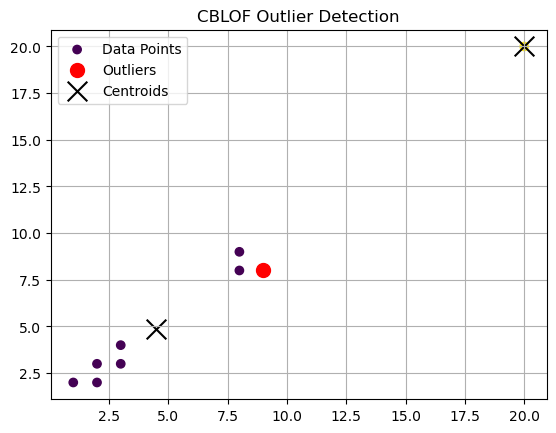

In [15]:
print("CBLOF Scores:", cblof_scores)
print("Outliers:", X[outliers])

# Step 6: Visualization
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', label='Data Points')
plt.scatter(X[outliers][:, 0], X[outliers][:, 1],
            color='red', label='Outliers', s=100)

plt.scatter(centroids[:, 0], centroids[:, 1],
            color='black', marker='x', s=200, label='Centroids')

plt.title("CBLOF Outlier Detection")
plt.legend()
plt.grid()
plt.show()